In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

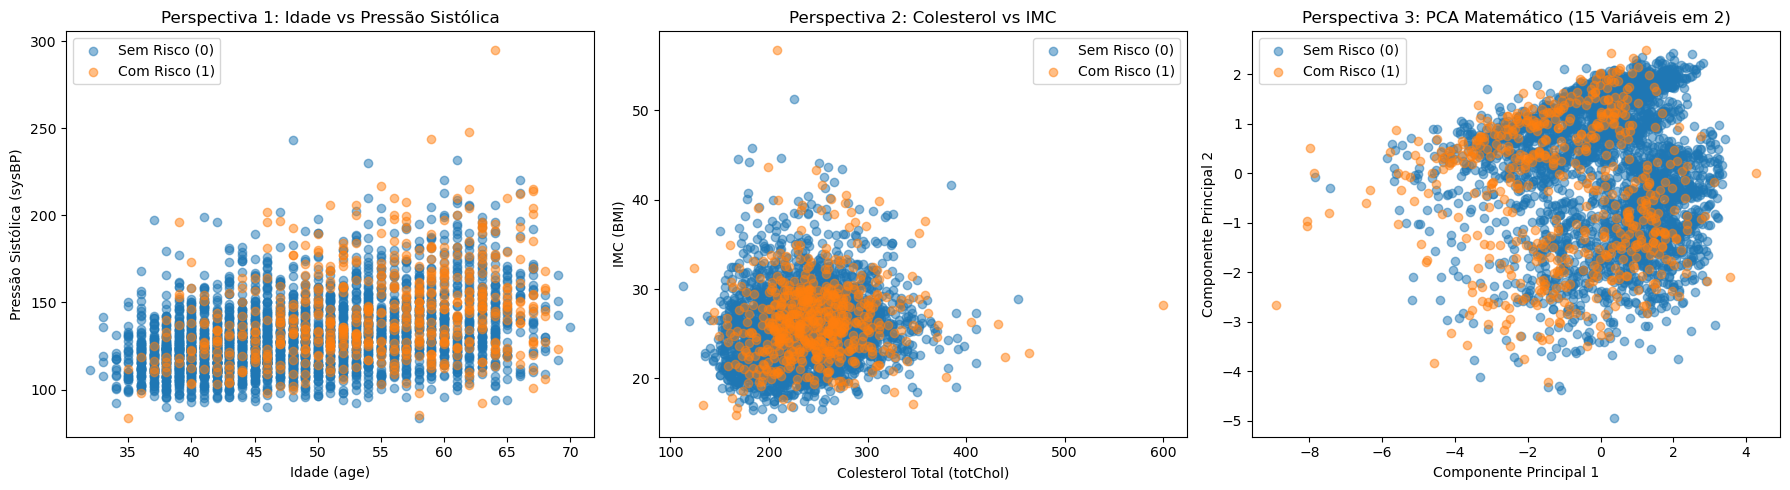

In [3]:
# 1. Carregar os dados reais
df = pd.read_csv('framingham.csv').dropna()
y = df['TenYearCHD'].values
X = df.drop('TenYearCHD', axis=1).values

# Criar a figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Gráfico 1: Idade vs Pressão Sistólica ---
axes[0].scatter(df[df['TenYearCHD']==0]['age'], df[df['TenYearCHD']==0]['sysBP'], label='Sem Risco (0)', alpha=0.5, color='#1f77b4')
axes[0].scatter(df[df['TenYearCHD']==1]['age'], df[df['TenYearCHD']==1]['sysBP'], label='Com Risco (1)', alpha=0.5, color='#ff7f0e')
axes[0].set_title('Perspect' \
'iva 1: Idade vs Pressão Sistólica')
axes[0].set_xlabel('Idade (age)')
axes[0].set_ylabel('Pressão Sistólica (sysBP)')
axes[0].legend()

# --- Gráfico 2: Colesterol vs IMC (BMI) ---
axes[1].scatter(df[df['TenYearCHD']==0]['totChol'], df[df['TenYearCHD']==0]['BMI'], label='Sem Risco (0)', alpha=0.5, color='#1f77b4')
axes[1].scatter(df[df['TenYearCHD']==1]['totChol'], df[df['TenYearCHD']==1]['BMI'], label='Com Risco (1)', alpha=0.5, color='#ff7f0e')
axes[1].set_title('Perspectiva 2: Colesterol vs IMC')
axes[1].set_xlabel('Colesterol Total (totChol)')
axes[1].set_ylabel('IMC (BMI)')
axes[1].legend()

# --- Gráfico 3: PCA "Na Unha" (100% NumPy, sem sklearn) ---
# A) Padronização (Z-score)
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_scaled = (X - mu) / sigma

# B) Calcular a Matriz de Covariância
cov_matrix = np.cov(X_scaled, rowvar=False)

# C) Calcular Autovalores e Autovetores (Eigenvalues & Eigenvectors)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# D) Ordenar em ordem decrescente e pegar os 2 principais (os que mais explicam os dados)
sorted_index = np.argsort(eigenvalues)[::-1]
top_2_eigenvectors = eigenvectors[:, sorted_index][:, 0:2]

# E) Multiplicar os dados originais pelos vetores para criar os 2 Eixos do PCA
X_pca = np.dot(X_scaled, top_2_eigenvectors)

# Plotar o PCA
axes[2].scatter(X_pca[y==0, 0], X_pca[y==0, 1], label='Sem Risco (0)', alpha=0.5, color='#1f77b4')
axes[2].scatter(X_pca[y==1, 0], X_pca[y==1, 1], label='Com Risco (1)', alpha=0.5, color='#ff7f0e')
axes[2].set_title('Perspectiva 3: PCA Matemático (15 Variáveis em 2)')
axes[2].set_xlabel('Componente Principal 1')
axes[2].set_ylabel('Componente Principal 2')
axes[2].legend()

plt.tight_layout()
plt.show()

In [4]:
df = pd.read_csv('framingham.csv')
df = df.dropna() #Remover linhas com valores nulos.

In [5]:
X = df.drop('TenYearCHD', axis=1).values
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

X_train = (X - mu) / sigma
y_train = df['TenYearCHD'].values


m, n = X_train.shape

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
def cost_function(X, y, w, b):
    cost_sum = 0

    for i in range (m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1 / m) * cost_sum

In [8]:
def gradient_function(X, y, w, b):
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])

        for j in range (n):
            grad_w[j] += (g - y[i]) * X[i,j]

    grad_b = (1/m) * grad_b
    grad_w = (1/m) * grad_w

    return grad_b, grad_w

In [9]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b)

        w = w - alpha * grad_w
        b = b - alpha * grad_b

        if i % 1000 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b)}")
    
    return w, b

In [10]:
def predict(X, w, b):
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g >= 0.5 else 0
    
    return preds

In [11]:
learning_rate = 0.01
iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, iterations)

predictions = predict(X_train, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"training accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6916509107946344
Iteration 1000: Cost 0.3936240946206504
Iteration 2000: Cost 0.37974313782734637
Iteration 3000: Cost 0.37746408598569337
Iteration 4000: Cost 0.37691855234174887
Iteration 5000: Cost 0.376761304102118
Iteration 6000: Cost 0.3767087467165314
Iteration 7000: Cost 0.37668831277009857
Iteration 8000: Cost 0.3766791000279172
Iteration 9000: Cost 0.3766744112770617
training accuracy: 85.61%
